# Chương 4: Mô Hình Chuỗi Hồi Quy và Tích Chập (Recurrent and Convolutional Sequence Models)

> *"Tổng thể lớn hơn tổng các phần của nó."* — Aristotle

Một câu không chỉ là tập hợp các từ — nghĩa của toàn câu phức tạp hơn nhiều so với nghĩa từng từ riêng lẻ. Đây là thách thức cốt lõi: **mô hình hóa chuỗi từ** thay vì chỉ từng từ đơn lẻ.

---

# 4.1 Phát Biểu Bài Toán (Problem Statement)

## Framework Tổng Quát: Encoding → Prediction

Cho chuỗi từ $w = w_1\ldots w_m$, hệ thống NLP cấp chuỗi gồm **hai bước tách biệt**:

**Bước 1 — Encoding (Biểu diễn):**

$$H = \text{Enc}(w) \tag{4.1}$$

**Bước 2 — Prediction (Dự đoán):**

$$y = \text{Predict}(H) \tag{4.2}$$

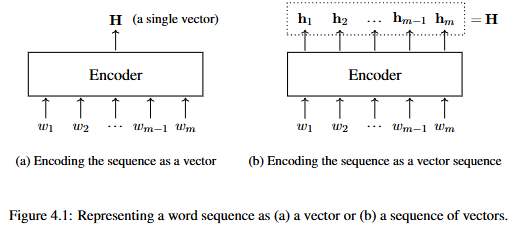

## Hai Dạng Biểu Diễn $H$

**Dạng (a) — Một vectơ duy nhất:**
Toàn bộ chuỗi nén thành một vectơ $H \in \mathbb{R}^d$ — dùng cho classification, sentiment analysis,...

**Dạng (b) — Chuỗi vectơ $h_1\ldots h_m$:**
Mỗi $h_i$ là **biểu diễn có ngữ cảnh** (contextualized representation) của từ $w_i$ trong toàn bộ chuỗi — dùng cho sequence labeling, NER, machine translation,...

> **Đây là điểm khác biệt then chốt so với Chương 3:** Word embedding (Ch.3) = biểu diễn từ đơn lẻ, độc lập. Contextualized representation (Ch.4) = biểu diễn từ **trong ngữ cảnh của cả câu** — cùng từ, câu khác → vector khác.

## Tại Sao Tách Encoding và Prediction?

**Ưu điểm của decoupling:**
- Cùng một encoder → dùng cho nhiều task khác nhau (chỉ thay predictor)
- Pre-train encoder một lần trên dữ liệu lớn → tái sử dụng cho nhiều downstream tasks
- Đây là nền tảng của paradigm **pre-training + fine-tuning** (BERT, GPT, v.v.)

## Các Dạng Output $y$

| Task | Dạng $y$ |
|---|---|
| Classification | Index của class / phân phối xác suất |
| Regression | Số thực |
| Sequence labeling | Chuỗi nhãn (1 nhãn/từ) |
| Machine translation | Chuỗi từ ngôn ngữ đích |

---

## Tổng Kết Mục 4.1

```
Input: w = w₁ w₂ ... wm (chuỗi từ)
         ↓
    Encoder Enc(·)
         ↓
    H (vectơ hoặc chuỗi vectơ)
         ↓
    Predictor Predict(·)
         ↓
    Output y (class / sequence / number)
```

Chương này tập trung vào các **neural encoder**:
- **Mục 4.2:** Recurrent Neural Networks (RNN, LSTM, GRU)
- **Mục 4.3:** Convolutional Neural Networks cho NLP
- **Mục 4.5:** Ứng dụng vào các NLP tasks

Bạn gửi nội dung phần 4.2 để tiếp tục nhé!

# 4.2 Mô Hình Hồi Quy (Recurrent Models)

---

## 4.2.1 RNN-based Language Models

### Bài Toán Language Modeling

Cho chuỗi từ $w_1\ldots w_m$, tính $\Pr(w_1,\ldots,w_m)$ bằng chain rule:

$$\Pr(w_1,\ldots,w_m) = \Pr(w_1)\cdot\Pr(w_2\mid w_1)\cdots\Pr(w_m\mid w_1,\ldots,w_{m-1}) \tag{4.3}$$

→ Bài toán quy về: **dự đoán từ tiếp theo** dựa trên toàn bộ lịch sử.

### Kiến Trúc RNN Language Model

**Embedding layer** — chuyển từ sang vector:

$$x_i = \text{Embed}(w_i) = \mathbf{1}_{w_i} C \tag{4.5}$$

**Recurrent unit** — cập nhật trạng thái ẩn:

$$h_i = \text{RNN}(h_{i-1}, x_i) \tag{4.4}$$

**Vanilla RNN:**

$$\text{RNN}(h_{i-1}, x_i) = \psi(h_{i-1}U + x_i V) \tag{4.6}$$

Khai triển đầy đủ:

$$h_i = \psi(h_{i-1}U + \mathbf{1}_{w_i}CV) \tag{4.7}$$

với $U \in \mathbb{R}^{d_h \times d_h}$, $V \in \mathbb{R}^{d_e \times d_h}$, $C \in \mathbb{R}^{|V| \times d_e}$.

**Output layer** — dự đoán từ tiếp theo:

$$y_{i+1} = \text{Softmax}(h_i O + b) \tag{4.8}$$

$$\Pr(w_{i+1} \mid w_1,\ldots,w_i) = y_{i+1}(w_{i+1}) \tag{4.9}$$

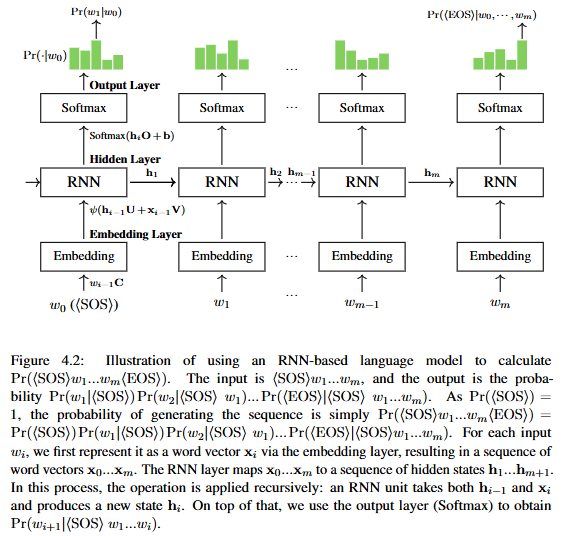

### Token Đặc Biệt $\langle\text{SOS}\rangle$ và $\langle\text{EOS}\rangle$

Để xử lý bắt đầu/kết thúc chuỗi, thêm token đặc biệt:

$$\Pr(\langle\text{SOS}\rangle, w_1,\ldots,w_m,\langle\text{EOS}\rangle) = \underbrace{\Pr(\langle\text{SOS}\rangle)}_{=1} \cdot \Pr(w_1\mid\langle\text{SOS}\rangle) \cdots \Pr(\langle\text{EOS}\rangle\mid\langle\text{SOS}\rangle,w_1,\ldots,w_m) \tag{4.10}$$

- Input sequence: $\langle\text{SOS}\rangle w_1\ldots w_m$
- Output sequence: $w_1\ldots w_m\langle\text{EOS}\rangle$

---

## 4.2.2 Training

### Cấu Trúc Input-Target Pairs

Với mỗi chuỗi $w = w_1\ldots w_{|w|}$, tạo các cặp:

$$\{(w_1, w_2),\ (w_2, w_3),\ \ldots,\ (w_{|w|-1}, w_{|w|})\}$$

| Bước | Input | Output dự đoán $\hat{y}$ | Gold-standard |
|---|---|---|---|
| 1 | $w_1$ | $\hat{y}_2$ | $w_2$ |
| 2 | $w_1, w_2$ | $\hat{y}_3$ | $w_3$ |
| $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ |
| $\|w\|-1$ | $w_1,\ldots,w_{|w|-2}$ | $\hat{y}_{|w|}$ | $w_{|w|}$ |

**Loss function** — cross-entropy cho từng bước, tổng trên toàn corpus:

$$L = \sum_{w \in S} \sum_{i=2}^{|w|} L(\hat{y}_i, \mathbf{1}_{w_i}) \tag{4.11}$$

**Cập nhật tham số:**

$$\theta_{\text{new}} = \theta_{\text{old}} - \eta \cdot \frac{\partial L}{\partial \theta} \tag{4.12}$$

$\theta$ gồm: $C, U, V, O, b$. Gradient tính qua **Backpropagation Through Time (BPTT)** — backprop qua toàn bộ chuỗi đã unroll.

### Vanishing/Exploding Gradient — Vấn Đề và Giải Pháp

**Nguyên nhân:** Chuỗi dài = mạng sâu theo chiều thời gian → chain rule nhân nhiều lần → gradient triệt tiêu hoặc bùng nổ.

**Các giải pháp:**

| Phương pháp | Cơ chế |
|---|---|
| **Regularization** | L1/L2 trên tham số → tránh gradient lớn |
| **Gradient Clipping** | Nếu $\|\partial L/\partial\theta\| > \tau$: rescale xuống $\frac{\tau}{\|\partial L/\partial\theta\|} \cdot \frac{\partial L}{\partial\theta}$ |
| **Truncated BPTT** | Chia chuỗi dài thành đoạn ngắn → backprop từng đoạn |
| **Improved Architectures** | LSTM, GRU — dùng memory mechanism (Mục 4.3) |
| **Khởi tạo tốt** | Random init ở vùng phù hợp, hoặc chỉ train output layer |
| **Non-saturating activations** | ReLU thay Sigmoid/Tanh → không bị vanishing |
| **Normalization** | Batch/Layer norm → ổn định phân phối activation |

> **Gradient Clipping** là kỹ thuật đơn giản và hiệu quả nhất cho exploding gradient:
> $$\frac{\partial L}{\partial\theta} \leftarrow \frac{\tau}{\max(\tau,\|\partial L/\partial\theta\|)} \cdot \frac{\partial L}{\partial\theta} \tag{4.13}$$
> Nếu norm gradient $\leq \tau$: giữ nguyên; nếu $> \tau$: scale xuống về $\tau$.

---

## 4.2.3 Xếp Chồng Nhiều Lớp RNN (Layer Stacking)

**Stacked RNN** — đầu ra lớp $l$ là đầu vào lớp $l+1$:

$$h_i^{l+1} = \text{RNN}(h_{i-1}^{l+1},\ h_i^l) \tag{4.14}$$

với quy ước $h_i^0 = x_i$ (word vector).

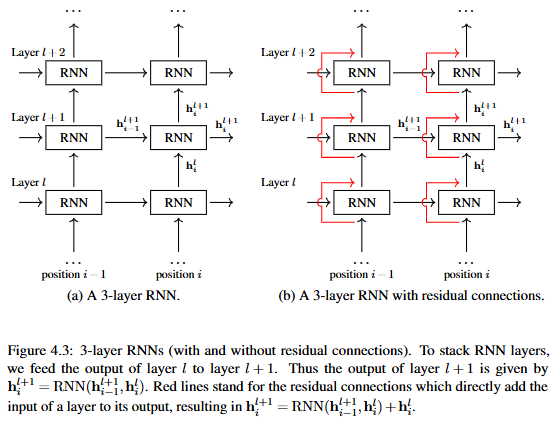

**Vấn đề:** Nhiều lớp → khó train hơn, thông tin khó flow qua.

**Giải pháp — Residual connections:**

$$h_i^{l+1} = \text{RNN}(h_{i-1}^{l+1},\ h_i^l) + h_i^l \tag{4.16}$$

Skip connection $+h_i^l$ cho phép:
- Thông tin từ lớp $l$ **"nhảy qua"** lên lớp $l+1$ trực tiếp
- Gradient có đường đi ngắn hơn trong BPTT
- Train mạng sâu ổn định hơn

---

## 4.2.4 Mô Hình Hai Chiều (Bi-directional RNN)

**Vấn đề của uni-directional RNN:** $h_i$ chỉ encode ngữ cảnh **trái** ($w_1\ldots w_i$) — không biết các từ bên phải.

**Giải pháp — Bi-directional RNN:** Chạy **hai RNN song song** theo hai hướng ngược nhau:

- **Left-to-right RNN:** $\overrightarrow{h}_i$ = encode ngữ cảnh $\{w_1,\ldots,w_i\}$
- **Right-to-left RNN:** $\overleftarrow{h}_i$ = encode ngữ cảnh $\{w_i,\ldots,w_m\}$

**Ghép nối (concatenate):**

$$h_i = [\overrightarrow{h}_i,\ \overleftarrow{h}_i] \tag{4.18}$$

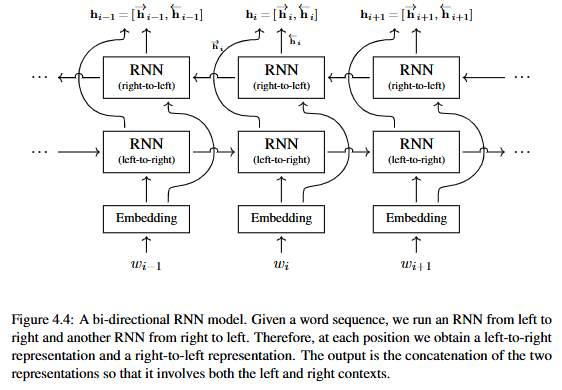

**Ưu điểm:** $h_i$ encode **toàn bộ ngữ cảnh** hai phía → biểu diễn giàu thông tin hơn nhiều so với uni-directional.

**Ứng dụng:** Dịch máy, phân tích cảm xúc, POS tagging, nhận dạng giọng nói,...

> **Lưu ý quan trọng:** Bi-directional RNN **không thể dùng cho language modeling** (vì khi dự đoán $w_i$ không được nhìn trước $w_{i+1}\ldots w_m$), nhưng rất phù hợp cho **encoding** (khi đã có toàn bộ câu).

---

## Tổng Kết Mục 4.2

```
RNN Language Model
  Input: ⟨SOS⟩ w₁ ... wm
  x_i = 1_{w_i} · C          (embedding)
  h_i = ψ(h_{i-1}U + x_i V)  (recurrent update)
  y_{i+1} = Softmax(h_i O+b)  (next word prediction)
  
Training: BPTT + cross-entropy loss

Vấn đề chuỗi dài:
  Vanishing gradient → LSTM/GRU (Mục 4.3)
  Exploding gradient → gradient clipping

Mở rộng:
  Stacked RNN: nhiều lớp → sâu hơn, cần residual connections
  Bi-directional: hai hướng → encode cả left + right context
  hl+1_i = RNN(hl+1_{i-1}, hl_i) + hl_i   (với residual)
  hi = [→hi, ←hi]                           (bi-directional)
```

| Biến thể | Đặc điểm | Dùng cho |
|---|---|---|
| **Uni-directional** | Chỉ nhìn trái | Language modeling, generation |
| **Bi-directional** | Nhìn cả hai chiều | Encoding, classification, NER |
| **Stacked** | Nhiều lớp theo chiều sâu | Tăng capacity |
| **Stacked + Residual** | Skip connections | Train sâu ổn định |

# 4.3 Bộ Nhớ (Memory)

---

## 4.3.1 Bộ Nhớ như một Hệ Thống

### Góc Nhìn Tâm Lý Học

**Multi-store model** (Atkinson & Shiffrin, 1968) chia bộ nhớ thành:
- **Sensory memory:** Kích thích tức thời, mất rất nhanh
- **Short-term memory:** Lưu tạm thời (ví dụ: số điện thoại)
- **Long-term memory:** Vĩnh viễn (ký ức tuổi thơ)

**Kết nối với RNN:**
- Hidden state $h_i$ ↔ **Short-term memory**: duy trì thông tin trong chuỗi, reset khi sang chuỗi mới
- Tham số mô hình ($U, V, C,...$) ↔ **Long-term memory**: lưu trữ kiến thức ngôn ngữ từ training, dùng mãi

### Ba Chức Năng của Hệ Thống Bộ Nhớ

**Encoding:** Input → vector đặc trưng (word embedding, sequence encoding)

**Update:** Lưu thông tin vào bộ nhớ — có thể là cập nhật vector đơn, hoặc datastore có index

**Retrieval:** Truy xuất thông tin khi cần — matching với query, hoặc trả về toàn bộ bộ nhớ

> **Vấn đề của vanilla RNN:** Cập nhật $h_i = \psi(h_{i-1}U + x_i V)$ **không kiểm soát** được lượng thông tin cũ giữ lại hay xóa đi — mô hình không học được cái gì cần nhớ, cái gì nên quên → khó học phụ thuộc dài hạn (long-term dependencies).

---

## 4.3.2 Long Short-Term Memory (LSTM)

**Ý tưởng cốt lõi:** Thêm **memory cell $c_i$** tách biệt với recurrent cell $h_i$, dùng **ba gates** để kiểm soát tường minh thông tin nào được nhớ, quên, và output.

$$(\mathbf{h}_i, \mathbf{c}_i) = \text{LSTM}(h_{i-1}, c_{i-1}, x_i) \tag{4.19}$$

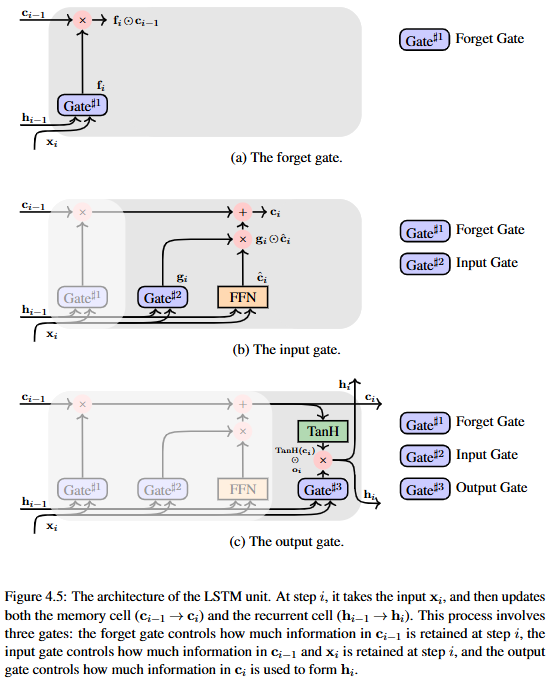

### Ba Bước của LSTM

**Bước 1 — Forget Gate (Quên):**

Quyết định bao nhiêu thông tin từ $c_{i-1}$ cần xóa:

$$f_i = \text{Sigmoid}(h_{i-1}U_f + x_i V_f + b_f) \tag{4.20}$$

$f_i \in [0,1]^{d_h}$ — $f_i^{(k)} = 0$: quên hoàn toàn chiều $k$; $f_i^{(k)} = 1$: giữ nguyên.

Thông tin giữ lại: $f_i \odot c_{i-1}$

**Bước 2 — Input Gate (Cập nhật):**

Tính thông tin mới muốn thêm vào:

$$\hat{c}_i = \text{TanH}(h_{i-1}U_c + x_i V_c + b_c) \tag{4.21}$$

Kiểm soát lượng thông tin mới được thêm:

$$g_i = \text{Sigmoid}(h_{i-1}U_g + x_i V_g + b_g) \tag{4.22}$$

**Cập nhật memory cell:**

$$c_i = f_i \odot c_{i-1} + g_i \odot \hat{c}_i \tag{4.23}$$

> **Ý nghĩa:** Quên cái cũ ($f_i \odot c_{i-1}$) + thêm cái mới ($g_i \odot \hat{c}_i$). Memory cell $c_i$ có **đường đi trực tiếp** qua thời gian không qua phi tuyến → gradient flow tốt hơn.

**Bước 3 — Output Gate (Output):**

Quyết định bao nhiêu memory cell được dùng cho output:

$$o_i = \text{Sigmoid}(h_{i-1}U_o + x_i V_o + b_o) \tag{4.24}$$

$$h_i = o_i \odot \text{TanH}(c_i) \tag{4.25}$$

### Tóm Tắt LSTM

```
Input: h_{i-1}, c_{i-1}, x_i
  ↓
Forget gate:  f_i = Sigmoid(h_{i-1}Uf + x_i Vf + bf)
Input gate:   g_i = Sigmoid(h_{i-1}Ug + x_i Vg + bg)
Candidate:    ĉ_i = TanH(h_{i-1}Uc + x_i Vc + bc)
  ↓
Memory cell:  c_i = f_i ⊙ c_{i-1} + g_i ⊙ ĉ_i
  ↓
Output gate:  o_i = Sigmoid(h_{i-1}Uo + x_i Vo + bo)
Output:       h_i = o_i ⊙ TanH(c_i)
```

**Tham số:** $U_f, U_c, U_g, U_o \in \mathbb{R}^{d_h \times d_h}$, $V_f, V_c, V_g, V_o \in \mathbb{R}^{d_e \times d_h}$, $b_f, b_c, b_g, b_o \in \mathbb{R}^{d_h}$ — nhiều hơn vanilla RNN ~4 lần.

> **Tại sao LSTM giải quyết vanishing gradient?** Memory cell $c_i = f_i \odot c_{i-1} + g_i \odot \hat{c}_i$ có gradient chảy **trực tiếp** qua phép cộng không qua activation phi tuyến → gradient không bị triệt tiêu theo thời gian dài.

---

## 4.3.3 Gated Recurrent Units (GRU)

**Ý tưởng:** Đơn giản hóa LSTM — **bỏ memory cell riêng biệt**, chỉ dùng **hai gates** thay ba.

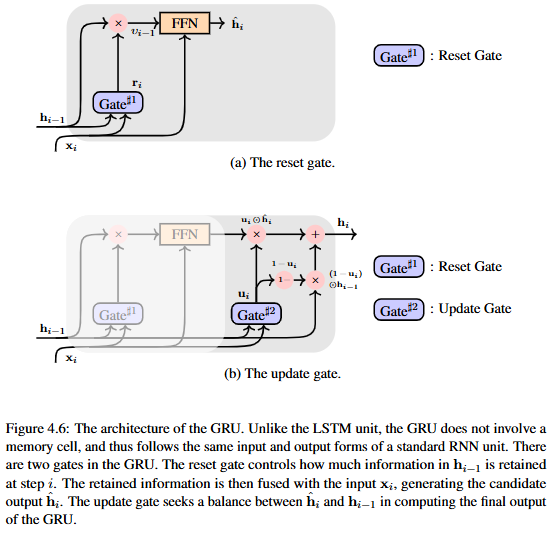

### Kiến Trúc GRU

**Reset gate** — kiểm soát bao nhiêu $h_{i-1}$ được giữ lại:

$$r_i = \text{Sigmoid}(h_{i-1}U_r + x_i V_r + b_r) \tag{4.26}$$

$$\upsilon_{i-1} = r_i \odot h_{i-1} \tag{4.27}$$

**Candidate state** — thông tin mới dựa trên $\upsilon_{i-1}$ và $x_i$:

$$\hat{h}_i = \text{TanH}(\upsilon_{i-1}U_h + x_i V_h + b_h) \tag{4.28}$$

**Update gate** — cân bằng giữa giữ cũ và thêm mới:

$$u_i = \text{Sigmoid}(h_{i-1}U_u + x_i V_u + b_u) \tag{4.29}$$

**Output — nội suy tuyến tính:**

$$h_i = u_i \odot \hat{h}_i + (1 - u_i) \odot h_{i-1} \tag{4.30}$$

> **Ý nghĩa của (4.30):** Khi $u_i = 1$: lấy hoàn toàn $\hat{h}_i$ (thông tin mới). Khi $u_i = 0$: giữ nguyên $h_{i-1}$ (nhớ cũ). GRU **học được** khi nào nên cập nhật và khi nào nên giữ nguyên.

**Tham số:** $U_r, U_h, U_u \in \mathbb{R}^{d_h \times d_h}$, $V_r, V_h, V_u \in \mathbb{R}^{d_e \times d_h}$, $b_r, b_h, b_u \in \mathbb{R}^{d_h}$ — ít hơn LSTM.

---

## So Sánh Vanilla RNN, LSTM, GRU

| | Vanilla RNN | LSTM | GRU |
|---|---|---|---|
| **Memory cell** | ✗ | ✓ ($c_i$ riêng biệt) | ✗ (dùng $h_i$) |
| **Số gates** | 0 | 3 (forget, input, output) | 2 (reset, update) |
| **Vanishing gradient** | Nghiêm trọng | Giải quyết tốt | Giải quyết tốt |
| **Số tham số** | Ít nhất | Nhiều nhất | Trung bình |
| **Tốc độ** | Nhanh nhất | Chậm nhất | Trung bình |
| **Hiệu suất thực tế** | Kém với chuỗi dài | Tốt | Tương đương LSTM |

---

## Tổng Kết Mục 4.3

```
Vấn đề vanilla RNN:
  Không kiểm soát thông tin nào cần nhớ/quên
  → Vanishing gradient với chuỗi dài

LSTM — giải pháp tường minh:
  Memory cell c_i (đường đi gradient trực tiếp)
  + 3 gates (forget, input, output)
  c_i = f_i ⊙ c_{i-1} + g_i ⊙ ĉ_i   (forget + add)
  h_i = o_i ⊙ TanH(c_i)               (output)

GRU — phiên bản nhẹ hơn:
  Không có memory cell riêng
  2 gates (reset, update)
  h_i = u_i ⊙ ĥ_i + (1-u_i) ⊙ h_{i-1}  (interpolation)
```

> **Kết nối với Chương tiếp theo:** LSTM và GRU giải quyết phụ thuộc dài hạn tốt hơn vanilla RNN, nhưng vẫn có giới hạn — thông tin đầu chuỗi vẫn có thể bị "pha loãng" qua nhiều bước. **Attention mechanism** (Chương 5) sẽ giải quyết triệt để vấn đề này bằng cách cho phép mô hình trực tiếp "nhìn" vào bất kỳ vị trí nào trong chuỗi.

# 4.4 Mô Hình Tích Chập (Convolutional Models)

---

## 4.4.1 Phép Tích Chập (Convolution)

### Nguyên Lý Cơ Bản

CNN dùng **filter (kernel)** trượt qua dữ liệu đầu vào, tính tổng có trọng số trong **receptive field** tại mỗi vị trí → tạo ra **feature map**.

**Ví dụ 2D** — cho ma trận đầu vào $A$ và filter $W$:

$$A = \begin{pmatrix}1&9&7\\3&1&2\\0&1&-1\end{pmatrix}, \quad W = \begin{pmatrix}2&0\\2&2\end{pmatrix} \tag{4.31, 4.32}$$

Áp dụng filter lên góc trên-trái:

$$\text{Conv}\!\left(\begin{pmatrix}1&9\\3&1\end{pmatrix}, W\right) = 1\times2 + 9\times0 + 3\times2 + 1\times2 = 10 \tag{4.33}$$

Trượt filter toàn bộ $A$ → feature map:

$$\text{Conv}(A, W) = \begin{pmatrix}10&24\\8&2\end{pmatrix} \tag{4.34}$$

**Dạng tổng quát** — filter $W$ có cùng kích thước với sub-array $a_p$:

$$v_p = \text{Conv}(a_p, W) = a_p \cdot W = \sum_{k=1}^{|W|} a_p(k) \cdot W(k) \tag{4.38}$$

### Stride và Padding

**Stride:** Bước nhảy của filter khi trượt. Stride lớn → downsample → feature map nhỏ hơn.

**Padding:** Thêm giá trị giả (thường là 0) xung quanh biên để kiểm soát kích thước output.

**Ví dụ** với $A = \begin{pmatrix}1&9\\7&3\end{pmatrix}$, sau khi zero-pad thành $4\times4$:

$$\text{Conv}_{\text{stride}=1}(A_{\text{padding}}, W) = \begin{pmatrix}2&20&18\\14&22&24\\0&14&6\end{pmatrix} \tag{4.41}$$

$$\text{Conv}_{\text{stride}=2}(A_{\text{padding}}, W) = \begin{pmatrix}2&18\\0&6\end{pmatrix} \tag{4.42}$$

> **Lưu ý kỹ thuật:** Trong deep learning thực ra dùng **cross-correlation** (không flip filter) thay vì convolution toán học thuần túy. Vì filter weights được học từ đầu, phép flip không ảnh hưởng gì → các framework bỏ qua để tối ưu tốc độ.

---

## 4.4.2 CNN cho Sequence Modeling

**Input:** Chuỗi word vectors $x_1\ldots x_m$ → ma trận $X \in \mathbb{R}^{m \times d_e}$.

**Receptive field:** Kích thước $r \times d_e$ — xét $r$ từ liên tiếp và toàn bộ $d_e$ chiều cùng lúc.

**Padding** hai đầu chuỗi để giữ nguyên độ dài:

| Vị trí | Input | Receptive Field | Output |
|---|---|---|---|
| 0 | $x_0 = \mathbf{0}$ (padding) | — | — |
| 1 | $x_1$ | $\{x_0, x_1, x_2\}$ | $h_1$ |
| 2 | $x_2$ | $\{x_1, x_2, x_3\}$ | $h_2$ |
| $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ |
| $m$ | $x_m$ | $\{x_{m-1}, x_m, x_{m+1}\}$ | $h_m$ |
| $m+1$ | $x_{m+1} = \mathbf{0}$ (padding) | — | — |

**Output tại vị trí $i$** với activation function:

$$v_i = \psi(\text{Conv}(a_i, W)) \tag{4.43}$$

**Nhiều filters** — dùng $d_h$ filters để học nhiều đặc trưng khác nhau:

$$v_i^{(k)} = \psi^{(k)}(\text{Conv}(a_i^{(k)}, W^{(k)})), \quad h_i = [v_i^{(1)},\ldots,v_i^{(d_h)}] \tag{4.44, 4.45}$$

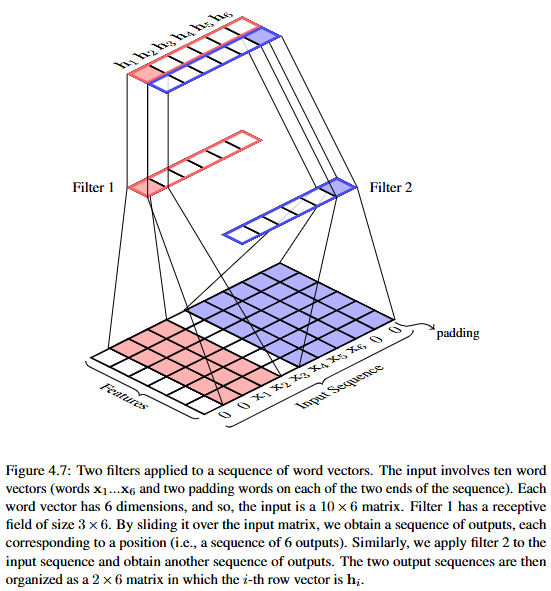

### Stacked CNN

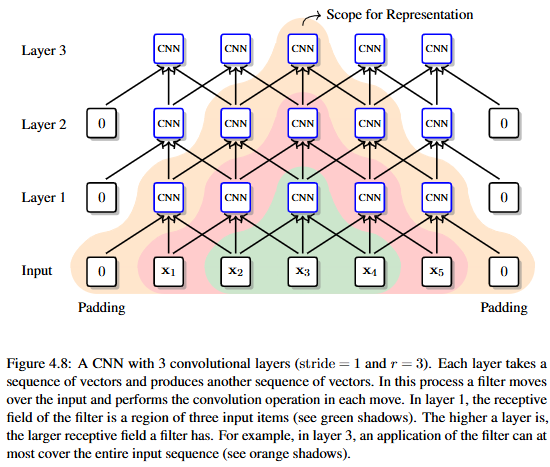

**Xếp chồng convolutional layers** → **receptive field mở rộng theo cấp số nhân**:
- Layer 1: mỗi $h_i$ nhìn 3 từ
- Layer 2: mỗi $h_i$ nhìn 5 từ
- Layer 3: mỗi $h_i$ nhìn 7 từ (có thể toàn bộ chuỗi)

**Ưu điểm:** Layers cao học được **đặc trưng cấp cao** và **phụ thuộc tầm xa** mà không cần receptive field lớn ở mỗi lớp.

**Pooling** — khi cần một vector duy nhất cho cả chuỗi:
- **Max-pooling:** lấy giá trị lớn nhất mỗi chiều
- **Average-pooling:** lấy trung bình mỗi chiều

---

## 4.4.3 Xử Lý Thông Tin Vị Trí (Positional Information)

**Vấn đề:** CNN có **translation invariance** — không biết vị trí tuyệt đối của từ trong chuỗi. $h_i$ encode cửa sổ xung quanh $x_i$, không encode chính xác thứ tự bên trong cửa sổ đó.

**Giải pháp — Positional Encoding:**

$$e_i = \text{Merge}(x_i, \text{PE}(i)) \tag{4.46}$$

Thay $x_i$ bằng $e_i$ trong mô hình — hoàn toàn model-agnostic.

---

### 1. Offset-based Positional Encoding (Scalar)

Dạng đơn giản nhất — dùng index tuyệt đối:

$$\text{PE}(i) = i - i_0 \tag{4.47}$$

Chuẩn hóa về $[0,1]$:

$$\text{PE}(i) = \frac{i - i_0}{i_{\max} - i_0} \tag{4.49}$$

Ghép vào word vector:

$$e_i = [x_i,\ \text{PE}(i)] \tag{4.50}$$

**Hạn chế:** Chỉ là scalar, không đủ biểu diễn phong phú cho cấu trúc vị trí phức tạp.

---

### 2. Sinusoidal Positional Encoding (Vector)

**Ý tưởng:** Biểu diễn vị trí như hệ số trong **hệ số đếm tuần hoàn** (carrying system) nhưng dùng hàm lượng giác thay số nguyên → vector liên tục.

**Tần số giảm dần** theo chiều $k$:

$$\omega_k = \frac{1}{b_{\text{model}}^{k/d_{\text{model}}}} \tag{4.54}$$

**Encoding (Vaswani et al., 2017)** với $b_{\text{model}} = 10000$:

$$\text{PE}(i, 2k) = \sin\!\left(\frac{i}{10000^{2k/d_{\text{model}}}}\right) \tag{4.57}$$

$$\text{PE}(i, 2k+1) = \cos\!\left(\frac{i}{10000^{2k/d_{\text{model}}}}\right) \tag{4.58}$$

Chiều chẵn dùng sin, chiều lẻ dùng cos. Tần số cao ở chiều nhỏ (thay đổi nhanh), tần số thấp ở chiều lớn (thay đổi chậm) → giống hệ đếm nhị phân nhưng liên tục.

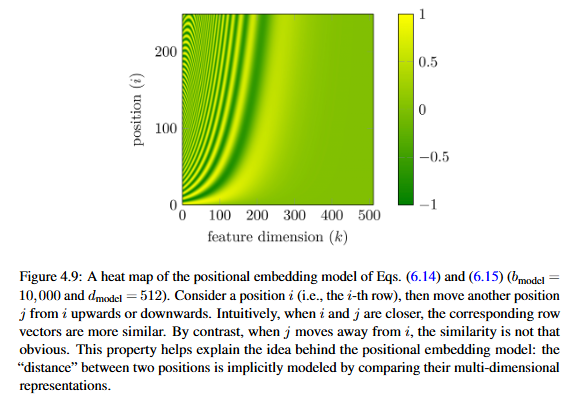

**Tính chất quan trọng** — $\text{PE}(i+\mu)$ viết được qua $\text{PE}(i)$ tuyến tính:

$$\text{PE}(i+\mu, 2k) = \text{PE}(i,2k)\cdot\text{PE}(\mu,2k+1) + \text{PE}(i,2k+1)\cdot\text{PE}(\mu,2k) \tag{4.61}$$

→ Mô hình có thể học được **quan hệ tương đối** giữa các vị trí.

**Cách kết hợp** (Vaswani et al., 2017) — cộng trực tiếp (thay vì nối):

$$e_i = x_i + \text{PE}(i) \tag{4.63}$$

Yêu cầu $|\text{PE}(i)| = |x_i| = d_e$.

---

### 3. Learnable Positional Encoding

Thay vì dùng công thức cố định, **học PE như tham số** — tạo lookup table:

$$C_{\text{PE}} = \begin{pmatrix}\text{PE}(1)\\\vdots\\\text{PE}(m_{\max})\end{pmatrix} \in \mathbb{R}^{m_{\max} \times d_e} \tag{4.64}$$

Train cùng với word embeddings theo gradient descent. Ưu điểm: linh hoạt, adapt với dữ liệu. Nhược điểm: không tổng quát ra ngoài $m_{\max}$.

### 4. Absolute vs Relative Positional Encoding

**Absolute PE:** Mô tả vị trí tuyệt đối $i$ trong chuỗi (các phương pháp trên).

**Relative PE:** Mô tả **khoảng cách tương đối** giữa hai vị trí $i$ và $j$:

$$\text{PE}(i, j) = |i - j| \tag{4.65}$$

→ Nền tảng của các kiến trúc tiên tiến hơn (Chương 6, 8).

---

## Tổng Kết Mục 4.4

```
CNN cho Sequences:
  Input: X ∈ ℝ^{m × de}
  Filter W: receptive field r × de
  Output: h_i = [ψ(Conv(a_i, W^(1))), ..., ψ(Conv(a_i, W^(dh)))]

Ưu điểm:
  ✓ Weight sharing → ít tham số, scale tốt
  ✓ Parallel computation (không sequential như RNN)
  ✓ Multi-layer → receptive field mở rộng exponential

Nhược điểm:
  ✗ Translation invariance → không biết vị trí tuyệt đối

Giải pháp — Positional Encoding:
  ei = xi + PE(i)  (hoặc concatenate)

  Offset-based:  PE(i) = i/imax       (scalar, đơn giản)
  Sinusoidal:    PE(i,2k) = sin(i·ωk) (vector, tính chất tương đối)
  Learnable:     CPE được train cùng model
```

**So sánh RNN vs CNN cho sequence modeling:**

| | RNN/LSTM/GRU | CNN |
|---|---|---|
| **Thứ tự từ** | Tự nhiên (sequential) | Cần positional encoding |
| **Phụ thuộc dài** | Qua hidden state (có thể mất) | Qua stacking lớp |
| **Tính song song** | Khó (sequential) | **Dễ (parallel)** |
| **Số tham số** | Nhiều hơn | Ít hơn (weight sharing) |
| **Ứng dụng** | LM, generation | Classification, NER |

> **Kết nối với Chương 6:** Positional encoding sinusoidal là thành phần cốt lõi của **Transformer** (Vaswani et al., 2017). Transformer kết hợp positional encoding với **Self-Attention** (thay vì convolution) → tạo ra kiến trúc state-of-the-art cho NLP hiện đại.

# 4.5 Các Ví Dụ Ứng Dụng (Examples)

---

## 4.5.1 Phân Loại Văn Bản (Text Classification)

**Bài toán:** Gán nhãn $c \in C$ cho chuỗi từ $w_1\ldots w_m$:

$$\hat{c} = \arg\max_{c \in C} \Pr(c \mid x_1\ldots x_m) \tag{4.66, 4.67}$$

**Framework Encoder-Predictor:**

**Bước 1 — Encoding:** Chuỗi → một vectơ duy nhất:

$$H = \text{Encode}(x_1\ldots x_m) \in \mathbb{R}^{d_h} \tag{4.68}$$

**Bước 2 — Prediction:**

$$\Pr(\cdot \mid H) = \text{Softmax}(H \cdot U + b) \tag{4.69}$$

**Ví dụ — CNN Text Classifier (Kim, 2014):**

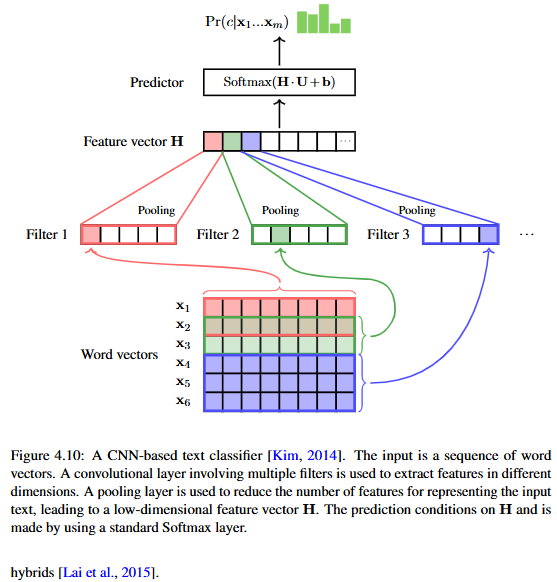

- $d_h$ filters trượt qua chuỗi → mỗi filter cho chuỗi features
- **Max-pooling** rút gọn mỗi filter về **1 giá trị** → $H \in \mathbb{R}^{d_h}$
- Softmax dự đoán class

**Training:** Cross-entropy loss + gradient descent + regularization (Chương 2).

> **Đơn giản nhưng hiệu quả:** Kiến trúc này là baseline mạnh cho text classification. Mở rộng: deep CNNs, character-level CNNs, recurrent-convolutional hybrids.

---

## 4.5.2 Nhận Dạng Giọng Nói End-to-End (Speech Recognition)

**Bài toán:** Acoustic signals $x_1\ldots x_m$ → transcription $y_1\ldots y_n$ (chuỗi ký tự/phoneme/subword).

$$\hat{y}_1\ldots\hat{y}_n = \arg\max_{y_1\ldots y_n} \Pr(y_1\ldots y_n \mid x_1\ldots x_m) \tag{4.70}$$

**Thách thức:** $n \ll m$ (transcription ngắn hơn nhiều so với acoustic frames) → cần alignment.

**Kiến Trúc:**

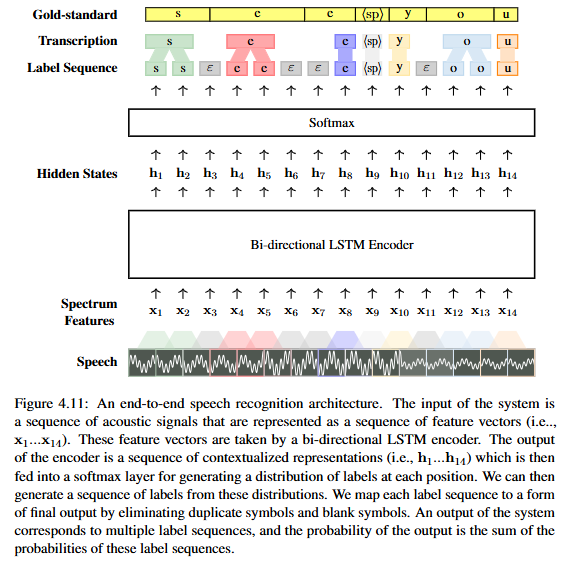

**Bước 1 — Encoding:**
$$h_1\ldots h_m = \text{Encode}(x_1\ldots x_m) \tag{4.71}$$
Dùng **multi-layer bi-directional LSTM**.

**Bước 2 — Label distribution tại mỗi vị trí:**
$$\Pr(\cdot \mid h_i) = \text{Softmax}(h_i \cdot U + b)$$

**Bước 3 — Xác suất label sequence:**
$$\Pr(l_1\ldots l_m \mid H) = \prod_{i=1}^m \Pr(l_i \mid h_i) \tag{4.72}$$

**Bước 4 — Post-processing:** Label sequence chứa duplicates và blank symbol $\varepsilon$ → collapse:

```
s s ε e e ε ε e ⟨sp⟩ y ε o o u
  → s ε e ε ε e ⟨sp⟩ y ε o u   (merge duplicates)
  → s e e ⟨sp⟩ y o u            (remove ε)
```

**Connectionist Temporal Classification (CTC):**

Nhiều label sequences có thể map về cùng transcription $y_1\ldots y_n$. Gọi $B(y_1\ldots y_n)$ là tập tất cả label sequences tương ứng:

$$\Pr(y_1\ldots y_n \mid x_1\ldots x_m) = \sum_{l_1\ldots l_m \in B(y_1\ldots y_n)} \Pr(l_1\ldots l_m \mid H) \tag{4.73}$$

**Training:** Maximize log-likelihood trên tập $S$ gồm các cặp (transcription, acoustic):

$$\hat{\theta} = \arg\max_\theta \sum_{(y,x) \in S} \log\Pr(y_1\ldots y_n \mid x_1\ldots x_m, \theta) \tag{4.74}$$

Tổng trong (4.73) tính hiệu quả qua **dynamic programming (forward-backward algorithm)**.

**Decoding:** Dùng **Viterbi decoding** — tìm label sequence tốt nhất thay vì tổng toàn bộ.

---

## 4.5.3 Sequence Labeling với LSTM và Mô Hình Đồ Thị

**Bài toán:** Gán nhãn $y_i \in V_y$ cho mỗi từ $x_i$ trong chuỗi:

$$\hat{y}_1\ldots\hat{y}_m = \arg\max_{y_1\ldots y_m} \Pr(y_1\ldots y_m \mid x_1\ldots x_m) \tag{4.75}$$

Ứng dụng: word segmentation, POS tagging, NER, chunking.

**Kiến Trúc BiLSTM + CRF:**

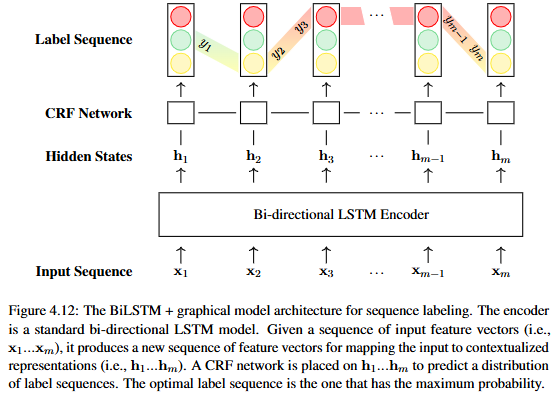

**Bước 1 — Bi-directional LSTM Encoding:**
$$h_1\ldots h_m = \text{Encode}(x_1\ldots x_m) \tag{4.76}$$

Bi-LSTM cho $h_i$ encode cả ngữ cảnh trái và phải — quan trọng vì nhãn phụ thuộc hai chiều.

**Bước 2 — Tại sao cần CRF thay vì Softmax đơn giản?**

Softmax độc lập: dự đoán $y_i$ chỉ từ $h_i$ → bỏ qua phụ thuộc giữa các nhãn liên tiếp. Ví dụ: trong NER, nhãn "I-PER" không thể đứng sau "B-LOC" → cần mô hình hóa **transition** giữa nhãn.

### Linear-Chain CRF

$$\Pr(y_1\ldots y_m \mid h_1\ldots h_m) = \frac{\exp(\text{Score}(y_1\ldots y_m, h_1\ldots h_m))}{Z(h_1\ldots h_m)} \tag{4.79}$$

**Score function** — tổng feature functions tại mỗi vị trí:

$$\text{Score}(y_1\ldots y_m, h_1\ldots h_m) = \sum_{i=1}^m \sum_{j=1}^J f_j(y_i, y_{i-1}, h_i) \tag{4.81}$$

**Hai loại features:**

**Transition features** — quan hệ giữa nhãn liên tiếp:
$$f_1(y_i, y_{i-1}, h_i) = u(y_{i-1}, y_i) \tag{4.82}$$
$u \in \mathbb{R}^{|V_y| \times |V_y|}$ là ma trận transition weight.

**Emission features** — quan hệ giữa nhãn và input:
$$f_2(y_i, y_{i-1}, h_i) = g_i(y_i), \quad g_i = h_i \cdot v \tag{4.83, 4.84}$$

**Score dạng ma trận:**

$$\text{Score}(y_1\ldots y_m, h_1\ldots h_m) = \sum_{i=1}^m (y_{i-1} \cdot u + h_i \cdot v) \cdot y_i^\top \tag{4.85}$$

Chỉ gồm các phép nhân ma trận → implement như neural network thông thường.

**Training và Inference:**
- Normalization factor $Z(h_1\ldots h_m) = \sum_{y'} \exp(\text{Score}(y', H))$ tính qua **forward algorithm**
- Tìm optimal sequence qua **Viterbi algorithm** (dynamic programming)
- Train bằng maximum likelihood + gradient descent

> **Ưu điểm của BiLSTM-CRF:** Không cần feature engineering thủ công — model tự học features từ raw input. Đây là backbone của nhiều state-of-the-art NER, POS tagging systems.

---

## 4.5.4 Mô Hình Lai RNN-CNN cho Language Modeling

**Ý tưởng:** Kết hợp RNN (mô hình hóa chuỗi từ) + CNN (mô hình hóa cấu trúc ký tự bên trong từ).

**Vấn đề của word embedding thông thường:** Mỗi từ = một vector → bỏ qua cấu trúc nội bộ → khó với **từ hiếm** và ngôn ngữ có vocabulary lớn.

**Giải pháp — Character-aware Word Representation (Kim et al., 2016):**

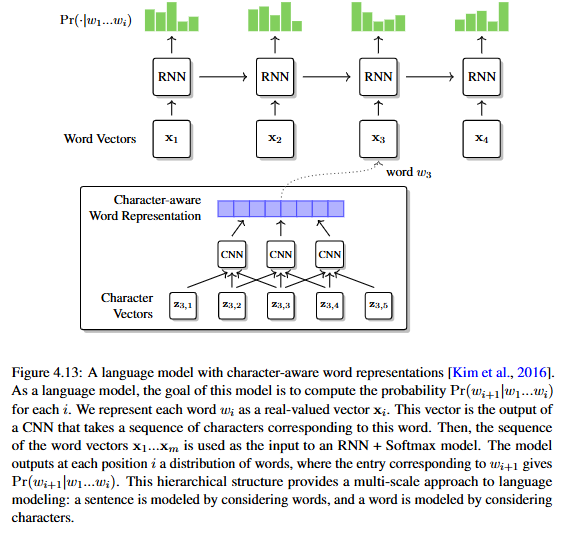

**Cấu trúc phân cấp:**

**Cấp 1 — Ký tự → Từ (CNN):**

Từ $w_i$ gồm $\text{len}_i$ ký tự, mỗi ký tự có vector $z_{i,1}\ldots z_{i,\text{len}_i}$:

$$x_i = \text{CNN}(z_{i,1}\ldots z_{i,\text{len}_i}, W) = \text{Pooling}(\text{TanH}(\text{Conv}(z_{i,1}\ldots z_{i,\text{len}_i}, W))) \tag{4.87}$$

**Cấp 2 — Từ → Câu (RNN):**

$$\Pr(w_{i+1} \mid w_1\ldots w_i) = \Pr(w_{i+1} \mid h_i), \quad h_i = \text{RNN}(h_{i-1}, x_i) \tag{4.86}$$

**Ưu điểm của kiến trúc phân cấp:**
- "uncopyrightable" → CNN học được cấu trúc "un-", "copy-", "-right-", "-able" → vector tốt dù từ hiếm
- Chia sẻ thông tin giữa các từ có cùng morphology ("run", "running", "runner")
- Vocabulary của character embedding nhỏ hơn nhiều so với word embedding

---

## Tổng Kết Mục 4.5

```
Text Classification:
  x₁...xm → CNN Encoder → H (single vector) → Softmax → Pr(class)
  Key: max-pooling gộp chuỗi thành 1 vector

Speech Recognition (CTC):
  Acoustic frames → Bi-LSTM → label distribution → collapse → transcription
  Key: CTC xử lý alignment không đồng đều

Sequence Labeling (BiLSTM-CRF):
  x₁...xm → Bi-LSTM → h₁...hm → CRF → y₁...ym
  Key: CRF mô hình hóa transition giữa nhãn

Character-aware LM:
  Chars → CNN → word vector xi → RNN → Pr(next word)
  Key: kiến trúc phân cấp (char → word → sentence)
```

| Task | Encoder | Predictor | Dạng output |
|---|---|---|---|
| Text classification | CNN | Softmax | 1 class |
| Speech recognition | Bi-LSTM | CTC | Chuỗi ký tự |
| Sequence labeling | Bi-LSTM | CRF | Chuỗi nhãn |
| Language modeling | RNN + CNN | Softmax | Phân phối từ |

> **Kết nối:** Chương 4 giới thiệu RNN/CNN như công cụ encoding chuỗi. Chương 5 sẽ giới thiệu **Attention mechanism** — cho phép mô hình "nhìn" trực tiếp vào bất kỳ vị trí nào trong chuỗi thay vì phụ thuộc vào hidden state tích lũy → nền tảng của Transformer (Chương 6).